In [1]:
import xarray
import netCDF4
import matplotlib
import numpy
import cartopy
import pandas
import cdsapi

print("✅ xarray", xarray.__version__)
print("✅ netCDF4", netCDF4.__version__)
print("✅ matplotlib", matplotlib.__version__)
print("✅ numpy", numpy.__version__)
print("✅ cartopy", cartopy.__version__)
print("✅ pandas", pandas.__version__)
print("✅ cdsapi", cdsapi.__version__)

✅ xarray 2026.4.0
✅ netCDF4 1.7.4
✅ matplotlib 3.10.9
✅ numpy 2.4.4
✅ cartopy 0.25.0
✅ pandas 3.0.2


AttributeError: module 'cdsapi' has no attribute '__version__'

In [2]:
import cdsapi
print("✅ cdsapi imported successfully")

✅ cdsapi imported successfully


In [3]:
# Run this cell to create the .cdsapirc file
# Replace YOUR-UID and YOUR-API-KEY with your actual values from your CDS profile

cdsapi_config = """url: https://cds.climate.copernicus.eu/api/v2
key: igaliya@gmail.com:Climatedata2026!
"""

import os
config_path = os.path.join(os.path.expanduser("~"), ".cdsapirc")

with open(config_path, "w") as f:
    f.write(cdsapi_config)

print(f"✅ .cdsapirc file created at: {config_path}")

✅ .cdsapirc file created at: C:\Users\Galiya\.cdsapirc


In [4]:
import cdsapi
c = cdsapi.Client()
print("✅ CDS connection successful")

✅ CDS connection successful


In [5]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'sis-heat-and-cold-spells',
    {
        'variable': 'heat_wave_days',
        'definition': 'euroheat',
        'period': 'future',
        'experiment': ['rcp4_5', 'rcp8_5'],
        'ensemble_statistic': 'ensemble_mean',
        'format': 'zip',
    },
    'heatwave_days_europe.zip'
)

print("✅ Download complete!")

2026-04-30 14:03:30,936 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/sis-heat-and-cold-spells


Exception: Exception: Climate Data Store API endpoint not found

It seems you are trying to access an API endpoint that does not exist.

It is possible that you are pointing to an outdated API endpoint which has been removed/renamed. 

Your api client version and/or configuration file may need to be updated.

For users of the standard cdsapi Python library, please proceed as follows:
- update your cdsapi client to the latest version available
- update your .cdsapirc file as expected ("url" should be set to https://cds.climate.copernicus.eu/api and "key" should be set to your API key WITHOUT the deprecated `<UID>:` prefix)

For users of the ecmwf-datastores-client Python library (recommended for advanced users), please ensure that your ecmwf-datastores-client version is updated and your .ecmwfdatastoresrc file is correctly configured.

If you are trying to access a REST API endpoint directly, please refer to the documentation for more information on how to access REST API endpoints: htt

In [6]:
pip install --upgrade cdsapi

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
cdsapi_config = """url: https://cds.climate.copernicus.eu/api
key: c32830b8-7898-487e-ae0a-f166b1d6bb61
"""

import os
config_path = os.path.join(os.path.expanduser("~"), ".cdsapirc")

with open(config_path, "w") as f:
    f.write(cdsapi_config)

print(f"✅ .cdsapirc file updated at: {config_path}")

✅ .cdsapirc file updated at: C:\Users\Galiya\.cdsapirc


In [8]:
import cdsapi
c = cdsapi.Client()
print("✅ CDS connection successful")

✅ CDS connection successful


In [9]:
import cdsapi

dataset = "sis-heat-and-cold-spells"
request = {
    "variable": ["heat_wave_days"],
    "definition": "health_related",
    "experiment": [
        "rcp4_5",
        "rcp8_5"
    ],
    "ensemble_statistic": ["ensemble_members_average"]
}

client = cdsapi.Client()
print("⏳ Submitting request to CDS...")
client.retrieve(dataset, request).download("heatwave_days_europe.zip")
print("✅ Download complete! File saved as heatwave_days_europe.zip")

2026-04-30 14:23:53,490 INFO [2025-01-29T00:00:00] This dataset is no longer supported by the data providers. Data and documentation are provided as is. Users are encouraged to use our [Forum](https://forum.ecmwf.int/) to raise any item of discussion with respect to this dataset.
2026-04-30 14:23:53,493 INFO Request ID is 296c2244-c9fe-4496-8243-04dc897dc03c


⏳ Submitting request to CDS...


2026-04-30 14:23:53,557 INFO status has been updated to accepted
2026-04-30 14:24:08,018 INFO status has been updated to successful


6c3e5b7b30cba23c106163ff959c92d1.zip:   0%|          | 0.00/194M [00:00<?, ?B/s]

Recovering from connection error [("Connection broken: ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)", ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))], attempt 1 of 500
Retrying in 120 seconds


6c3e5b7b30cba23c106163ff959c92d1.zip:  59%|#####9    | 115M/194M [00:00<?, ?B/s]

✅ Download complete! File saved as heatwave_days_europe.zip


In [10]:
import zipfile
import os

# Unzip the file
with zipfile.ZipFile("heatwave_days_europe.zip", "r") as zip_ref:
    zip_ref.extractall("heatwave_data")

# List all extracted files
print("📁 Files extracted:")
for f in os.listdir("heatwave_data"):
    print(f" —", f)

📁 Files extracted:
 — HWD_EU_health_rcp45_mean_v1.0.nc
 — HWD_EU_health_rcp85_mean_v1.0.nc


In [11]:
import xarray as xr

# Open both files
rcp45 = xr.open_dataset("heatwave_data/HWD_EU_health_rcp45_mean_v1.0.nc")
rcp85 = xr.open_dataset("heatwave_data/HWD_EU_health_rcp85_mean_v1.0.nc")

# Explore the structure
print("=" * 50)
print("RCP 4.5 dataset:")
print(rcp45)
print("\n" + "=" * 50)
print("RCP 8.5 dataset:")
print(rcp85)

RCP 4.5 dataset:
<xarray.Dataset> Size: 102MB
Dimensions:        (time: 100, lat: 425, lon: 599)
Coordinates:
  * time           (time) datetime64[ns] 800B 1986-01-01 ... 2085-01-01
  * lat            (lat) float64 3kB 30.1 30.2 30.3 30.4 ... 72.2 72.3 72.4 72.5
  * lon            (lon) float64 5kB -24.9 -24.8 -24.7 -24.6 ... 34.7 34.8 34.9
    height         float64 8B ...
Data variables:
    HWD_EU_health  (time, lat, lon) float32 102MB ...
Attributes:
    title:          Processed EURO-CORDEX future climate data for the health ...
    conventions:    CF-1.6
    project:        Copernicus Climate Change Service Sectoral Information Sy...
    source:         Processing of bias-corrected EURO-CORDEX data by VITO
    contact:        bd_rma@vito.be
    creation_date:  Mon Jun 24 13:32:30 2019
    institution:    VITO (https://vito.be/en)

RCP 8.5 dataset:
<xarray.Dataset> Size: 102MB
Dimensions:        (time: 100, lat: 425, lon: 599)
Coordinates:
  * time           (time) datetime64[ns] 

In [12]:
import numpy as np

# Check time range and basic statistics
print("📅 Time range:", rcp45.time.values[0], "→", rcp45.time.values[-1])
print()

# Look at a few time snapshots
print("📊 Basic statistics for RCP 4.5 (heatwave days per year):")
print(f"  First period (1986): mean = {float(rcp45.HWD_EU_health.isel(time=0).mean()):.1f} days")
print(f"  Mid period   (2035): mean = {float(rcp45.HWD_EU_health.isel(time=49).mean()):.1f} days")
print(f"  Last period  (2085): mean = {float(rcp45.HWD_EU_health.isel(time=99).mean()):.1f} days")
print()
print("📊 Basic statistics for RCP 8.5 (heatwave days per year):")
print(f"  First period (1986): mean = {float(rcp85.HWD_EU_health.isel(time=0).mean()):.1f} days")
print(f"  Mid period   (2035): mean = {float(rcp85.HWD_EU_health.isel(time=49).mean()):.1f} days")
print(f"  Last period  (2085): mean = {float(rcp85.HWD_EU_health.isel(time=99).mean()):.1f} days")

📅 Time range: 1986-01-01T00:00:00.000000000 → 2085-01-01T00:00:00.000000000

📊 Basic statistics for RCP 4.5 (heatwave days per year):
  First period (1986): mean = 3.2 days
  Mid period   (2035): mean = 10.6 days
  Last period  (2085): mean = 18.7 days

📊 Basic statistics for RCP 8.5 (heatwave days per year):
  First period (1986): mean = 3.2 days
  Mid period   (2035): mean = 11.7 days
  Last period  (2085): mean = 38.7 days


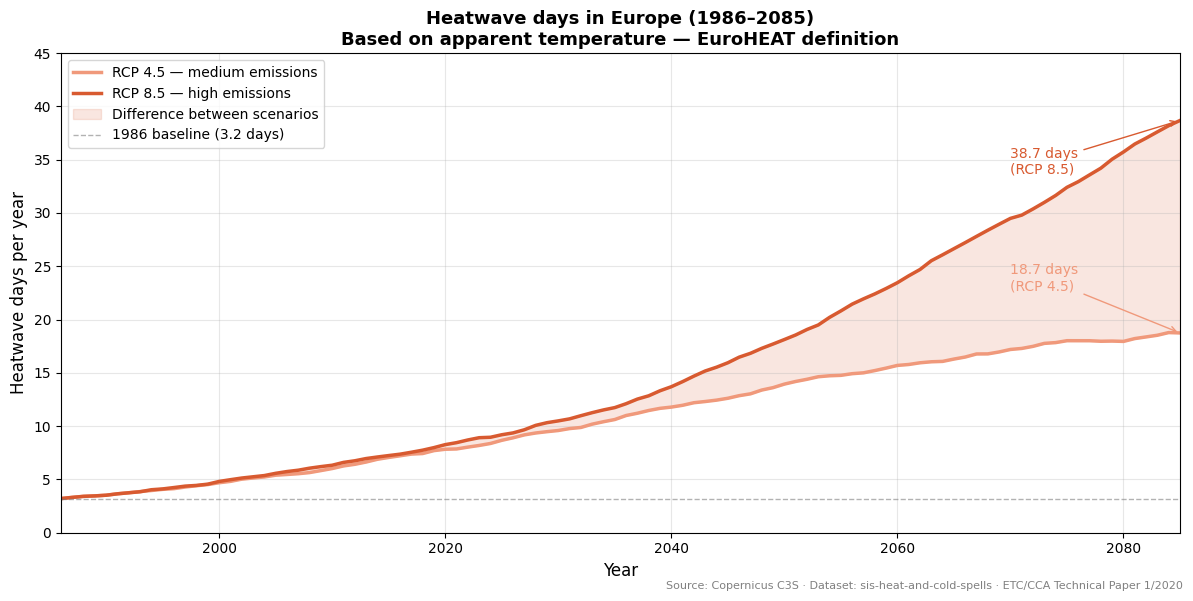

✅ Chart saved as heatwave_timeseries_europe.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate European mean for each year
years = rcp45.time.dt.year.values
mean_rcp45 = rcp45.HWD_EU_health.mean(dim=['lat', 'lon']).values
mean_rcp85 = rcp85.HWD_EU_health.mean(dim=['lat', 'lon']).values

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot both scenarios
ax.plot(years, mean_rcp45, 
        color='#F0997B', linewidth=2.5, 
        label='RCP 4.5 — medium emissions')
ax.plot(years, mean_rcp85, 
        color='#D85A30', linewidth=2.5, 
        label='RCP 8.5 — high emissions')

# Fill the gap between scenarios
ax.fill_between(years, mean_rcp45, mean_rcp85, 
                alpha=0.15, color='#D85A30',
                label='Difference between scenarios')

# Add reference line at 1986 baseline
ax.axhline(y=mean_rcp45[0], color='gray', 
           linestyle='--', linewidth=1, alpha=0.6,
           label=f'1986 baseline ({mean_rcp45[0]:.1f} days)')

# Annotations
ax.annotate(f'{mean_rcp85[-1]:.1f} days\n(RCP 8.5)', 
            xy=(2085, mean_rcp85[-1]),
            xytext=(2070, mean_rcp85[-1] - 5),
            fontsize=10, color='#D85A30',
            arrowprops=dict(arrowstyle='->', color='#D85A30'))

ax.annotate(f'{mean_rcp45[-1]:.1f} days\n(RCP 4.5)', 
            xy=(2085, mean_rcp45[-1]),
            xytext=(2070, mean_rcp45[-1] + 4),
            fontsize=10, color='#F0997B',
            arrowprops=dict(arrowstyle='->', color='#F0997B'))

# Styling
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Heatwave days per year', fontsize=12)
ax.set_title('Heatwave days in Europe (1986–2085)\nBased on apparent temperature — EuroHEAT definition', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(1986, 2085)
ax.set_ylim(0, 45)
ax.grid(True, alpha=0.3)

# Source note
fig.text(0.99, 0.01, 
         'Source: Copernicus C3S · Dataset: sis-heat-and-cold-spells · ETC/CCA Technical Paper 1/2020',
         ha='right', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('heatwave_timeseries_europe.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved as heatwave_timeseries_europe.png")

C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will

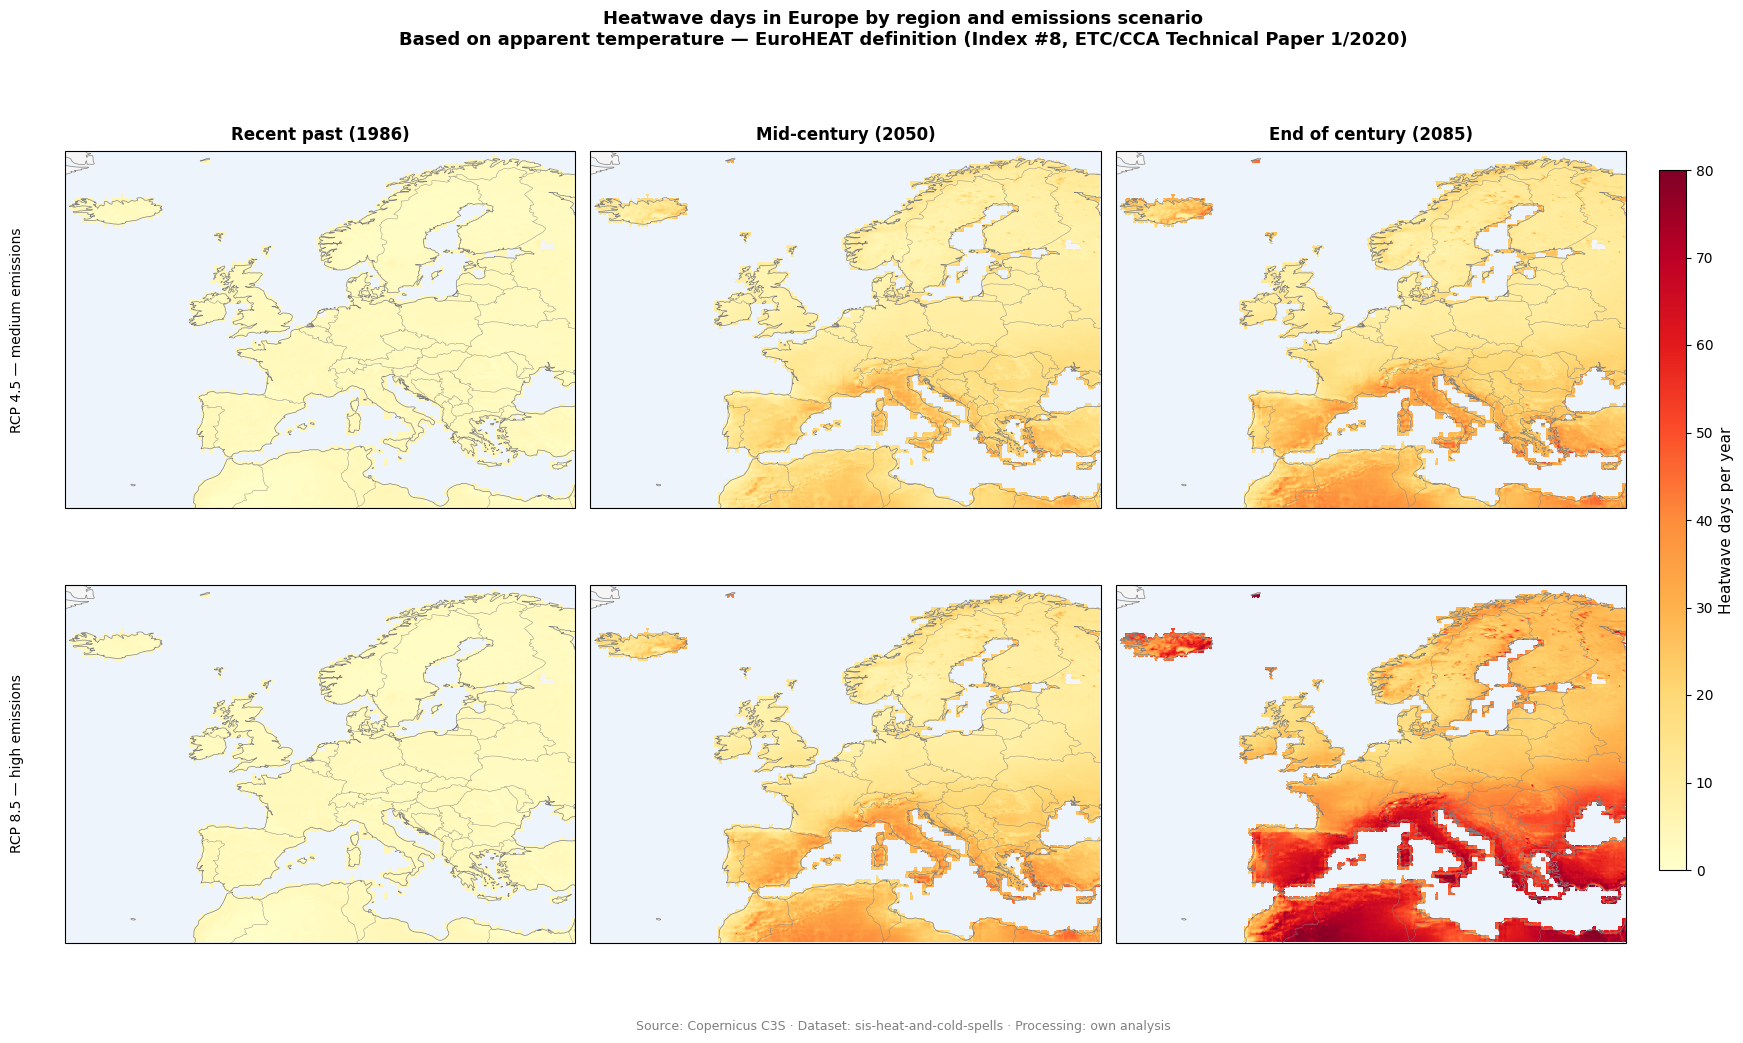

✅ Map saved as heatwave_map_europe.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Select three time periods to compare
periods = {
    'Recent past (1986)': 0,
    'Mid-century (2050)': 64,
    'End of century (2085)': 99
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10),
                          subplot_kw={'projection': ccrs.PlateCarree()})

# Colour scale — same for all panels for comparability
vmin, vmax = 0, 80

cmap = plt.cm.YlOrRd

for col, (period_name, time_idx) in enumerate(periods.items()):
    for row, (scenario, ds) in enumerate([('RCP 4.5 — medium emissions', rcp45), 
                                           ('RCP 8.5 — high emissions', rcp85)]):
        ax = axes[row, col]
        
        # Get data for this period
        data = ds.HWD_EU_health.isel(time=time_idx)
        
        # Plot
        im = ax.pcolormesh(ds.lon, ds.lat, data,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap, vmin=vmin, vmax=vmax)
        
        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
        ax.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
        ax.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
        
        # Set extent to Europe
        ax.set_extent([-25, 35, 30, 72], crs=ccrs.PlateCarree())
        
        # Titles
        if row == 0:
            ax.set_title(period_name, fontsize=12, fontweight='bold', pad=8)
        
        # Row labels
        if col == 0:
            ax.text(-0.08, 0.5, scenario,
                    transform=ax.transAxes,
                    fontsize=10, va='center', ha='right',
                    rotation=90, fontweight='500')

# Add shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Heatwave days per year', fontsize=11)

# Main title
fig.suptitle('Heatwave days in Europe by region and emissions scenario\n'
             'Based on apparent temperature — EuroHEAT definition (Index #8, ETC/CCA Technical Paper 1/2020)',
             fontsize=13, fontweight='bold', y=1.01)

# Source note
fig.text(0.5, -0.01,
         'Source: Copernicus C3S · Dataset: sis-heat-and-cold-spells · Processing: own analysis',
         ha='center', fontsize=9, color='gray')

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig('heatwave_map_europe.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Map saved as heatwave_map_europe.png")

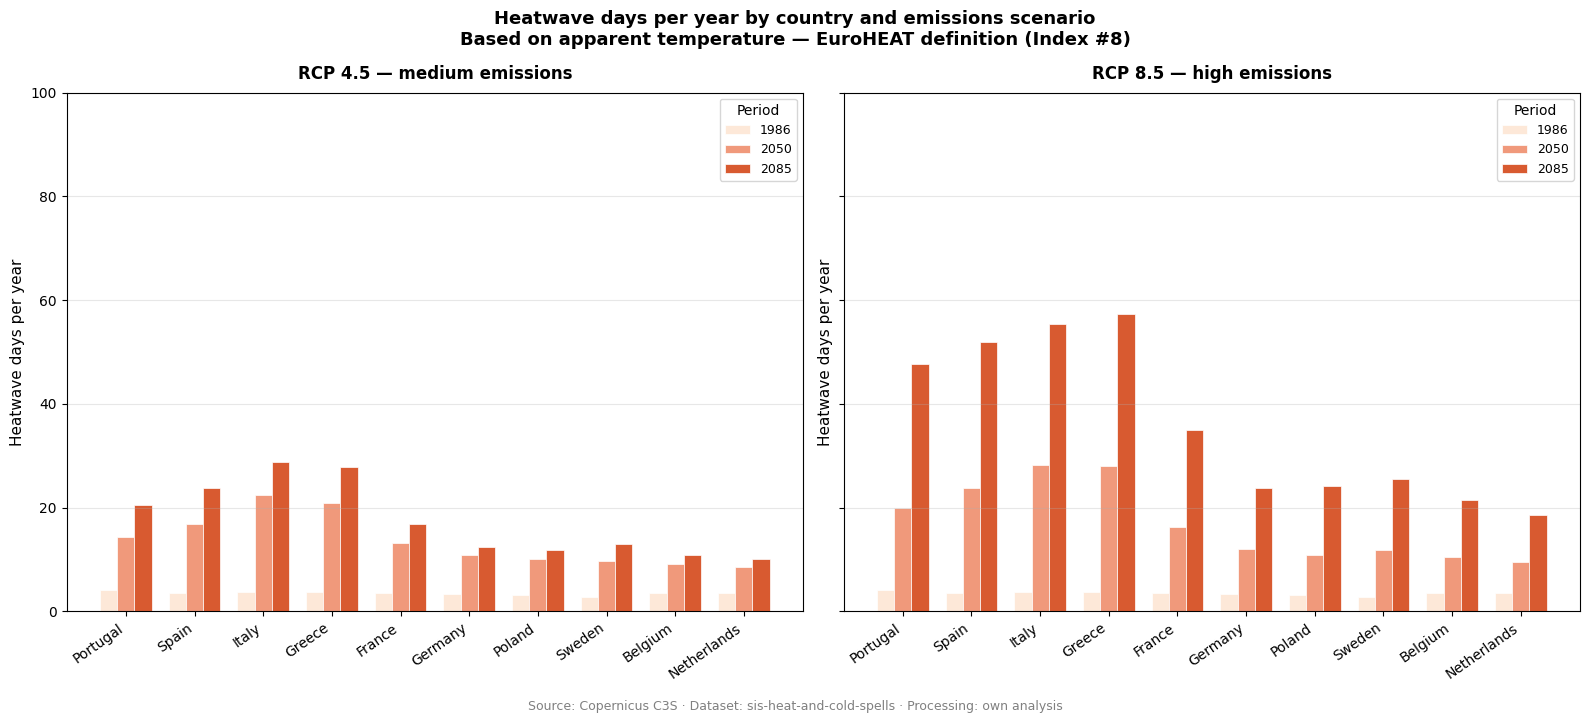

✅ Chart saved as heatwave_by_country.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Define country bounding boxes [lon_min, lon_max, lat_min, lat_max]
countries = {
    'Portugal':  [-9.5, -6.2, 37.0, 42.2],
    'Spain':     [-9.0, 3.3,  36.0, 43.8],
    'Italy':     [7.0,  18.5, 37.0, 47.1],
    'Greece':    [20.0, 26.5, 35.0, 42.0],
    'France':    [-5.0, 8.2,  42.3, 51.1],
    'Germany':   [6.0,  15.0, 47.3, 55.0],
    'Poland':    [14.1, 24.1, 49.0, 54.9],
    'Sweden':    [11.0, 24.2, 55.3, 69.1],
    'Belgium':   [2.5,  6.4,  49.5, 51.5],
    'Netherlands':[3.3, 7.2,  50.8, 53.6],
}

def country_mean(ds, bounds, time_idx):
    lon_min, lon_max, lat_min, lat_max = bounds
    subset = ds.HWD_EU_health.isel(time=time_idx).sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max)
    )
    return float(subset.mean())

# Calculate for 1986, 2050, 2085
time_periods = {'1986': 0, '2050': 64, '2085': 99}

results_45 = {country: {period: country_mean(rcp45, bounds, idx) 
              for period, idx in time_periods.items()}
              for country, bounds in countries.items()}

results_85 = {country: {period: country_mean(rcp85, bounds, idx) 
              for period, idx in time_periods.items()}
              for country, bounds in countries.items()}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

country_names = list(countries.keys())
x = np.arange(len(country_names))
width = 0.25

colors = {'1986': '#FDE8D8', '2050': '#F0997B', '2085': '#D85A30'}

for ax, (scenario_name, results) in zip(axes, [
    ('RCP 4.5 — medium emissions', results_45),
    ('RCP 8.5 — high emissions', results_85)
]):
    for i, (period, color) in enumerate(colors.items()):
        values = [results[c][period] for c in country_names]
        bars = ax.bar(x + i * width, values, width,
                      label=period, color=color,
                      edgecolor='white', linewidth=0.5)

    ax.set_title(scenario_name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x + width)
    ax.set_xticklabels(country_names, rotation=35, ha='right', fontsize=10)
    ax.set_ylabel('Heatwave days per year', fontsize=11)
    ax.legend(title='Period', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 100)

fig.suptitle('Heatwave days per year by country and emissions scenario\n'
             'Based on apparent temperature — EuroHEAT definition (Index #8)',
             fontsize=13, fontweight='bold')

fig.text(0.5, -0.02,
         'Source: Copernicus C3S · Dataset: sis-heat-and-cold-spells · Processing: own analysis',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('heatwave_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved as heatwave_by_country.png")

In [1]:
import os
import shutil

# Create a project folder
project_folder = "heatwave_analysis"
os.makedirs(project_folder, exist_ok=True)

# List of files to keep together
files_to_move = [
    "heatwave_days_europe.zip",
    "heatwave_timeseries_europe.png",
    "heatwave_map_europe.png", 
    "heatwave_by_country.png",
]

# Copy files to project folder
for f in files_to_move:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(project_folder, f))
        print(f"✅ Copied: {f}")
    else:
        print(f"⚠️ Not found: {f}")

# The data folder
if os.path.exists("heatwave_data"):
    shutil.copytree("heatwave_data", 
                    os.path.join(project_folder, "heatwave_data"),
                    dirs_exist_ok=True)
    print("✅ Copied: heatwave_data folder")

print(f"\n📁 All files saved in: {os.path.abspath(project_folder)}")

✅ Copied: heatwave_days_europe.zip
✅ Copied: heatwave_timeseries_europe.png
✅ Copied: heatwave_map_europe.png
✅ Copied: heatwave_by_country.png
✅ Copied: heatwave_data folder

📁 All files saved in: C:\Users\Galiya\heatwave_analysis


In [2]:
code = '''
# ============================================================
# Heatwave days in Europe — Analysis
# Index #8: Heatwave days based on apparent temperature
# EuroHEAT definition — ETC/CCA Technical Paper 1/2020
# Data source: Copernicus C3S, dataset: sis-heat-and-cold-spells
# Author: Galiya Ibragimova
# Date: April 2026
# ============================================================

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import os

# ── LOAD DATA ──
rcp45 = xr.open_dataset("heatwave_data/HWD_EU_health_rcp45_mean_v1.0.nc")
rcp85 = xr.open_dataset("heatwave_data/HWD_EU_health_rcp85_mean_v1.0.nc")

# ── CHART 1: TIME SERIES ──
years = rcp45.time.dt.year.values
mean_rcp45 = rcp45.HWD_EU_health.mean(dim=["lat", "lon"]).values
mean_rcp85 = rcp85.HWD_EU_health.mean(dim=["lat", "lon"]).values

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(years, mean_rcp45, color="#F0997B", linewidth=2.5, label="RCP 4.5 — medium emissions")
ax.plot(years, mean_rcp85, color="#D85A30", linewidth=2.5, label="RCP 8.5 — high emissions")
ax.fill_between(years, mean_rcp45, mean_rcp85, alpha=0.15, color="#D85A30", label="Difference between scenarios")
ax.axhline(y=mean_rcp45[0], color="gray", linestyle="--", linewidth=1, alpha=0.6, label=f"1986 baseline ({mean_rcp45[0]:.1f} days)")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Heatwave days per year", fontsize=12)
ax.set_title("Heatwave days in Europe (1986–2085)\\nBased on apparent temperature — EuroHEAT definition", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.set_xlim(1986, 2085)
ax.set_ylim(0, 45)
ax.grid(True, alpha=0.3)
fig.text(0.99, 0.01, "Source: Copernicus C3S · Dataset: sis-heat-and-cold-spells · ETC/CCA Technical Paper 1/2020", ha="right", fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("heatwave_analysis/heatwave_timeseries_europe.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Chart 1 saved")

# ── CHART 2: MAPS ──
periods = {"Recent past (1986)": 0, "Mid-century (2050)": 64, "End of century (2085)": 99}
fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={"projection": ccrs.PlateCarree()})
vmin, vmax = 0, 80
cmap = plt.cm.YlOrRd
for col, (period_name, time_idx) in enumerate(periods.items()):
    for row, (scenario, ds) in enumerate([("RCP 4.5 — medium emissions", rcp45), ("RCP 8.5 — high emissions", rcp85)]):
        ax = axes[row, col]
        data = ds.HWD_EU_health.isel(time=time_idx)
        im = ax.pcolormesh(ds.lon, ds.lat, data, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="gray")
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, color="gray")
        ax.add_feature(cfeature.OCEAN, color="#EEF4FB", zorder=0)
        ax.add_feature(cfeature.LAND, color="#F5F5F5", zorder=0)
        ax.set_extent([-25, 35, 30, 72], crs=ccrs.PlateCarree())
        if row == 0:
            ax.set_title(period_name, fontsize=12, fontweight="bold", pad=8)
        if col == 0:
            ax.text(-0.08, 0.5, scenario, transform=ax.transAxes, fontsize=10, va="center", ha="right", rotation=90, fontweight="500")
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Heatwave days per year", fontsize=11)
fig.suptitle("Heatwave days in Europe by region and emissions scenario\\nBased on apparent temperature — EuroHEAT definition (Index #8, ETC/CCA Technical Paper 1/2020)", fontsize=13, fontweight="bold", y=1.01)
fig.text(0.5, -0.01, "Source: Copernicus C3S · Dataset: sis-heat-and-cold-spells · Processing: own analysis", ha="center", fontsize=9, color="gray")
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig("heatwave_analysis/heatwave_map_europe.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Chart 2 saved")

# ── CHART 3: BY COUNTRY ──
countries = {
    "Portugal":    [-9.5, -6.2, 37.0, 42.2],
    "Spain":       [-9.0,  3.3, 36.0, 43.8],
    "Italy":       [ 7.0, 18.5, 37.0, 47.1],
    "Greece":      [20.0, 26.5, 35.0, 42.0],
    "France":      [-5.0,  8.2, 42.3, 51.1],
    "Germany":     [ 6.0, 15.0, 47.3, 55.0],
    "Poland":      [14.1, 24.1, 49.0, 54.9],
    "Sweden":      [11.0, 24.2, 55.3, 69.1],
    "Belgium":     [ 2.5,  6.4, 49.5, 51.5],
    "Netherlands": [ 3.3,  7.2, 50.8, 53.6],
}
def country_mean(ds, bounds, time_idx):
    lon_min, lon_max, lat_min, lat_max = bounds
    subset = ds.HWD_EU_health.isel(time=time_idx).sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    return float(subset.mean())
time_periods = {"1986": 0, "2050": 64, "2085": 99}
results_45 = {c: {p: country_mean(rcp45, b, i) for p, i in time_periods.items()} for c, b in countries.items()}
results_85 = {c: {p: country_mean(rcp85, b, i) for p, i in time_periods.items()} for c, b in countries.items()}
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
country_names = list(countries.keys())
x = np.arange(len(country_names))
width = 0.25
colors = {"1986": "#FDE8D8", "2050": "#F0997B", "2085": "#D85A30"}
for ax, (scenario_name, results) in zip(axes, [("RCP 4.5 — medium emissions", results_45), ("RCP 8.5 — high emissions", results_85)]):
    for i, (period, color) in enumerate(colors.items()):
        values = [results[c][period] for c in country_names]
        ax.bar(x + i * width, values, width, label=period, color=color, edgecolor="white", linewidth=0.5)
    ax.set_title(scenario_name, fontsize=12, fontweight="bold", pad=10)
    ax.set_xticks(x + width)
    ax.set_xticklabels(country_names, rotation=35, ha="right", fontsize=10)
    ax.set_ylabel("Heatwave days per year", fontsize=11)
    ax.legend(title="Period", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 100)
fig.suptitle("Heatwave days per year by country and emissions scenario\\nBased on apparent temperature — EuroHEAT definition (Index #8)", fontsize=13, fontweight="bold")
fig.text(0.5, -0.02, "Source: Copernicus C3S · Dataset: sis-heat-and-cold-spells · Processing: own analysis", ha="center", fontsize=9, color="gray")
plt.tight_layout()
plt.savefig("heatwave_analysis/heatwave_by_country.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Chart 3 saved")

print("\\n🎉 All charts regenerated successfully!")
'''

with open("heatwave_analysis/heatwave_analysis.py", "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Analysis script saved as heatwave_analysis/heatwave_analysis.py")

✅ Analysis script saved as heatwave_analysis/heatwave_analysis.py


In [1]:
import os
import shutil

# Create full folder structure
folders = [
    "eu-climate-hazard-indices/article_4_heatwave_analysis/data",
    "eu-climate-hazard-indices/article_4_heatwave_analysis/notebooks",
    "eu-climate-hazard-indices/article_4_heatwave_analysis/scripts",
    "eu-climate-hazard-indices/article_4_heatwave_analysis/outputs",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Created: {folder}")

# Copy data files
shutil.copy("heatwave_data/HWD_EU_health_rcp45_mean_v1.0.nc",
            "eu-climate-hazard-indices/article_4_heatwave_analysis/data/HWD_EU_health_rcp45_mean_v1.0.nc")
shutil.copy("heatwave_data/HWD_EU_health_rcp85_mean_v1.0.nc",
            "eu-climate-hazard-indices/article_4_heatwave_analysis/data/HWD_EU_health_rcp85_mean_v1.0.nc")
print("✅ Copied: data files")

# Copy outputs
for f in ["heatwave_timeseries_europe.png", "heatwave_map_europe.png", "heatwave_by_country.png"]:
    shutil.copy(f, f"eu-climate-hazard-indices/article_4_heatwave_analysis/outputs/{f}")
print("✅ Copied: output charts")

# Copy script
shutil.copy("heatwave_analysis/heatwave_analysis.py",
            "eu-climate-hazard-indices/article_4_heatwave_analysis/scripts/heatwave_days_analysis.py")
print("✅ Copied: script")

print(f"\n📁 Project folder ready at: {os.path.abspath('eu-climate-hazard-indices')}")

✅ Created: eu-climate-hazard-indices/article_4_heatwave_analysis/data
✅ Created: eu-climate-hazard-indices/article_4_heatwave_analysis/notebooks
✅ Created: eu-climate-hazard-indices/article_4_heatwave_analysis/scripts
✅ Created: eu-climate-hazard-indices/article_4_heatwave_analysis/outputs
✅ Copied: data files
✅ Copied: output charts


FileNotFoundError: [Errno 2] No such file or directory: 'heatwave_analysis/heatwave_analysis.py'

In [2]:
import os

# Check what's in the current directory
print("📁 Current directory:", os.getcwd())
print("\n📄 Files here:")
for f in os.listdir("."):
    print(" —", f)

📁 Current directory: C:\Users\Galiya\heatwave_analysis

📄 Files here:
 — .ipynb_checkpoints
 — eu-climate-hazard-indices
 — heatwave_analysis.py
 — heatwave_by_country.png
 — heatwave_data
 — heatwave_days_analysis.ipynb
 — heatwave_days_europe.zip
 — heatwave_map_europe.png
 — heatwave_timeseries_europe.png
